X shape: (96, 5, 3)
y shape: (96, 1)
(76, 5, 3)
(76, 1)
Epoch    0   Loss = 0.490322
Epoch  100   Loss = 0.042600
Epoch  200   Loss = 0.041946
Epoch  300   Loss = 0.041465
Epoch  400   Loss = 0.041100
Epoch  500   Loss = 0.040818
Epoch  600   Loss = 0.040597
Epoch  700   Loss = 0.040421
Epoch  800   Loss = 0.040278
Epoch  900   Loss = 0.040160
MSE : 2.1026
MAE : 1.1921


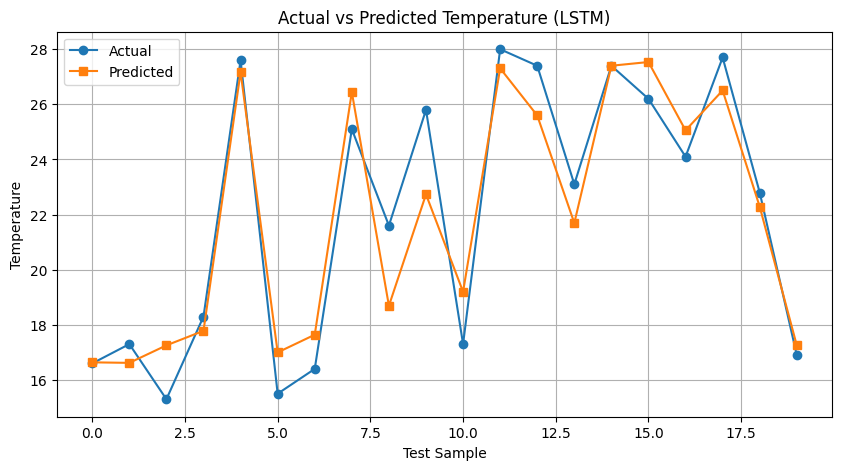

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================
# LOAD DATA
# =====================================================
# Same source data as the MLP / RNN projects.
# 100 rows: day, temp_morning, temp_afternoon, temp_evening, next_day_temp

df = pd.read_csv("temp_vanilla.csv")

# =====================================================
# BUILD SEQUENCES (extended lookback window)
# =====================================================
# Unlike the vanilla RNN (T=3, a single day's 3 readings treated as
# a sequence), here each SAMPLE is a window of T consecutive DAYS,
# each day contributing 3 features (morning/afternoon/evening).
# Target = next_day_temp of the LAST day in the window, i.e. the
# temperature of the day right after the window ends.
#
# This gives the LSTM an actual multi-day dependency to exploit,
# which a 3-step sequence does not really provide.

T = 5  # lookback window length, in days

feature_cols = ["temp_morning", "temp_afternoon", "temp_evening"]

features = df[feature_cols].values          # shape (100, 3)
targets  = df["next_day_temp"].values        # shape (100,)

def build_sequences(features, targets, T):
    X_seq, y_seq = [], []
    for i in range(len(features) - T + 1):
        X_seq.append(features[i : i + T])       # shape (T, 3)
        y_seq.append(targets[i + T - 1])         # next_day_temp of last day in window
    return np.array(X_seq), np.array(y_seq).reshape(-1, 1)

X, y = build_sequences(features, targets, T)
print("X shape:", X.shape)   # (N, T, 3)
print("y shape:", y.shape)   # (N, 1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)

# NOTE: because the windows overlap (sliding by 1 day), a random
# split can place adjacent, highly similar windows into train and
# test. For a small, illustrative scratch-code project this is an
# acceptable simplification; for a production model, a chronological
# (non-shuffled) split would be more appropriate.

# =====================================================
# STANDARD SCALING
# =====================================================
# StandardScaler expects 2D input, so we flatten (N, T, 3) -> (N*T, 3),
# fit/transform, then reshape back to (N, T, 3).

n_train, T_, d_ = X_train.shape
n_test = X_test.shape[0]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, d_)
X_test_flat  = X_test.reshape(-1, d_)

X_train_flat = x_scaler.fit_transform(X_train_flat)
X_test_flat  = x_scaler.transform(X_test_flat)

X_train = X_train_flat.reshape(n_train, T_, d_)
X_test  = X_test_flat.reshape(n_test, T_, d_)

y_train       = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# =====================================================
# LSTM PARAMETERS
# =====================================================

input_size  = 3   # d  = 3   (morning, afternoon, evening)
hidden_size = 16  # h  = 16
output_size = 1   # k  = 1
# T = 5 (defined above)

concat_size = hidden_size + input_size   # gates act on [h_prev ; x_t]

learning_rate = 0.001
epochs = 1000

# =====================================================
# WEIGHTS
# =====================================================

# np.random.seed(42)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Forget gate
Wf = np.random.randn(hidden_size, concat_size) * 0.1
bf = np.zeros((hidden_size, 1))

# Input gate
Wi = np.random.randn(hidden_size, concat_size) * 0.1
bi = np.zeros((hidden_size, 1))

# Candidate cell state
Wg = np.random.randn(hidden_size, concat_size) * 0.1
bg = np.zeros((hidden_size, 1))

# Output gate
Wo = np.random.randn(hidden_size, concat_size) * 0.1
bo = np.zeros((hidden_size, 1))

# Output layer : hidden -> output   (linear output for regression)
Why = np.random.randn(output_size, hidden_size) * 0.1
by  = np.zeros((output_size, 1))

# =====================================================
# TRAINING
# =====================================================

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for n in range(len(X_train)):

        # ==========================================
        # INITIAL HIDDEN / CELL STATE
        # ==========================================

        h_prev = np.zeros((hidden_size, 1))
        c_prev = np.zeros((hidden_size, 1))

        zs, fs, iis, gs, os_ = [], [], [], [], []
        hs = [h_prev]   # hs[0] = h_0 = 0
        cs = [c_prev]   # cs[0] = c_0 = 0

        # ==========================================
        # FORWARD PASS THROUGH TIME
        # ==========================================

        for t in range(T):

            x_t = X_train[n, t].reshape(-1, 1)       # shape (d, 1)
            z_t = np.vstack((hs[t], x_t))             # shape (h+d, 1)

            f_t = sigmoid(Wf @ z_t + bf)
            i_t = sigmoid(Wi @ z_t + bi)
            g_t = np.tanh(Wg @ z_t + bg)
            o_t = sigmoid(Wo @ z_t + bo)

            c_t = f_t * cs[t] + i_t * g_t
            h_t = o_t * np.tanh(c_t)

            zs.append(z_t)
            fs.append(f_t)
            iis.append(i_t)
            gs.append(g_t)
            os_.append(o_t)
            hs.append(h_t)
            cs.append(c_t)

        y_hat  = Why @ hs[T] + by
        target = np.array([[y_train[n, 0]]])

        loss = 0.5 * np.sum((y_hat - target) ** 2)
        total_loss += loss

        # ==========================================
        # OUTPUT LAYER GRADIENT
        # ==========================================

        dy = y_hat - target

        dWhy = dy @ hs[T].T
        dby  = dy

        # ==========================================
        # BPTT THROUGH THE LSTM GATES
        # ==========================================

        dWf = np.zeros_like(Wf); dbf = np.zeros_like(bf)
        dWi = np.zeros_like(Wi); dbi = np.zeros_like(bi)
        dWg = np.zeros_like(Wg); dbg = np.zeros_like(bg)
        dWo = np.zeros_like(Wo); dbo = np.zeros_like(bo)

        dh_next = Why.T @ dy                 # dh_T
        dc_next = np.zeros((hidden_size, 1)) # dc_T

        for t in reversed(range(T)):         # t = T-1, ..., 0

            h_t, c_t, c_prev_t = hs[t + 1], cs[t + 1], cs[t]
            f_t, i_t, g_t, o_t = fs[t], iis[t], gs[t], os_[t]
            z_t = zs[t]

            dh = dh_next

            # ---- output gate ----
            do     = dh * np.tanh(c_t)
            do_raw = do * o_t * (1 - o_t)          # sigmoid'(z) = o_t(1-o_t)

            # ---- cell state ----
            dc = dc_next + dh * o_t * (1 - np.tanh(c_t) ** 2)

            # ---- forget gate ----
            df     = dc * c_prev_t
            df_raw = df * f_t * (1 - f_t)

            # ---- input gate ----
            di     = dc * g_t
            di_raw = di * i_t * (1 - i_t)

            # ---- candidate cell ----
            dg     = dc * i_t
            dg_raw = dg * (1 - g_t ** 2)           # tanh'(z) = 1 - g_t^2

            dWf += df_raw @ z_t.T; dbf += df_raw
            dWi += di_raw @ z_t.T; dbi += di_raw
            dWg += dg_raw @ z_t.T; dbg += dg_raw
            dWo += do_raw @ z_t.T; dbo += do_raw

            dz = (Wf.T @ df_raw + Wi.T @ di_raw +
                  Wg.T @ dg_raw + Wo.T @ do_raw)

            dh_prev = dz[:hidden_size, :]   # gradient flowing into h_{t-1}
            # dx_t  = dz[hidden_size:, :]   # gradient into x_t (unused: input, not trainable)

            dc_next = dc * f_t
            dh_next = dh_prev

        # ==========================================
        # WEIGHT UPDATE
        # ==========================================

        Wf -= learning_rate * dWf; bf -= learning_rate * dbf
        Wi -= learning_rate * dWi; bi -= learning_rate * dbi
        Wg -= learning_rate * dWg; bg -= learning_rate * dbg
        Wo -= learning_rate * dWo; bo -= learning_rate * dbo

        Why -= learning_rate * dWhy
        by  -= learning_rate * dby

    loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}   Loss = {total_loss / len(X_train):.6f}"
        )

# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

    h_prev = np.zeros((hidden_size, 1))
    c_prev = np.zeros((hidden_size, 1))

    for t in range(T):

        x_t = X_test[n, t].reshape(-1, 1)
        z_t = np.vstack((h_prev, x_t))

        f_t = sigmoid(Wf @ z_t + bf)
        i_t = sigmoid(Wi @ z_t + bi)
        g_t = np.tanh(Wg @ z_t + bg)
        o_t = sigmoid(Wo @ z_t + bo)

        c_prev = f_t * c_prev + i_t * g_t
        h_prev = o_t * np.tanh(c_prev)

    y_hat = Why @ h_prev + by
    predictions.append(y_hat[0, 0])

predictions = np.array(predictions).reshape(-1, 1)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test

# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual, predictions)
mae = mean_absolute_error(actual, predictions)
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")

# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    actual,
    label="Actual",
    marker='o'
)

plt.plot(
    predictions,
    label="Predicted",
    marker='s'
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.title("Actual vs Predicted Temperature (LSTM)")

plt.legend()

plt.grid(True)

plt.show()